# A Practical Introduction to Logistic Regression

This notebook introduces logistic regression, a powerful statistical technique for modeling binary outcomes. A binary outcome is a variable that can only take two values, such as 'Yes' or 'No', 'Success' or 'Failure', or '1' or '0'.

To illustrate logistic regression, we will use the well-known Titanic dataset. Our goal will be to model the factors that influenced a passenger's survival during the disaster. This provides a compelling and intuitive way to understand the core concepts of logistic regression.

### What is Logistic Regression?

Unlike linear regression, which predicts a continuous value, logistic regression predicts the *probability* of an event occurring. It models the probability that the outcome variable belongs to a particular category. To do this, it models the *log-odds* of the event as a linear combination of the predictor variables.

We will again use `pandas` for data handling, `statsmodels` for modeling, and `seaborn` and `matplotlib` for visualization.

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels.api as sm
import numpy as np

### Loading and Preparing the Data

We'll load the Titanic dataset from Seaborn. The primary outcome variable we are interested in is `survived`, which is already coded as `1` for survived and `0` for did not survive. We will also use predictors like `pclass` (passenger class), `sex`, and `age`. The dataset contains some missing values, particularly in the `age` column, so we will drop rows with missing data for simplicity (a technique called *complete case analysis*).

In [6]:
# Load the Titanic dataset
titanic = sns.load_dataset('titanic')

# Drop rows with missing values in key columns
vars = ["survived", "pclass", "sex", "age"]
titanic = titanic[vars].dropna()

titanic.head()

,survived,pclass,sex,age
0,0,3,male,22.0
1,1,1,female,38.0
2,1,3,female,26.0
3,1,1,female,35.0
4,0,3,male,35.0


## Odds and Log-Odds: The Foundation of Logistic Regression

Logistic regression works with odds and log-odds, so let's understand these concepts first.

- **Probability (p):** The likelihood of an event occurring (e.g., probability of survival). It ranges from 0 to 1.
- **Odds:** The ratio of the probability of an event happening to the probability of it not happening: `Odds = p / (1 - p)`.
  - If odds = 1, the event is equally likely to occur as not.
  - If odds > 1, the event is more likely to occur.
  - If odds < 1, the event is less likely to occur.
- **Log-Odds:** The natural logarithm of the odds: `log(Odds)`. The log-odds scale is symmetric around 0, which makes it suitable for linear modeling.

Let's calculate the odds of survival for males and females.

In [7]:
# Calculate probability of survival by gender
c = pd.crosstab(titanic.sex, titanic.survived)
c['probability'] = c[1] / (c[0] + c[1])

# Calculate odds of survival
c['odds'] = c.probability / (1 - c.probability)
# Or more directly: c['odds'] = c[1] / c[0]

# Calculate log-odds
c['logodds'] = np.log(c.odds)

c

survived,0,1,probability,odds,logodds
sex,,,,,
female,64,197,0.754789,3.078125,1.124321
male,360,93,0.205298,0.258333,-1.353505


We can see that:
- The probability of survival for females was about 75%, while for males it was only 20%.
- The **odds** of survival for a female were about 3.0, meaning a female passenger was 3 times more likely to survive than not. For males, the odds were only 0.26.
- The **log-odds** for females is positive (1.11), while for males it is negative (-1.33), reflecting their respective chances of survival relative to a 50/50 baseline (which has a log-odds of 0).

The **odds ratio** comparing females to males is `3.01 / 0.26 = 11.5`. This means the odds of survival for a female were over 11 times higher than the odds for a male.

## A Basic Logistic Regression Model

Let's fit our first logistic regression model. We'll predict `survived` using only one predictor: `sex`. We use the `GLM` (Generalized Linear Model) function from `statsmodels` with a `Binomial` family, which specifies that our outcome is binary.

In [8]:
model = sm.GLM.from_formula("survived ~ sex", family=sm.families.Binomial(), data=titanic)
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               survived   No. Observations:                  714
Model:                            GLM   Df Residuals:                      712
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -375.35
Date:                Thu, 16 Oct 2025   Deviance:                       750.70
Time:                        14:42:44   Pearson chi2:                     714.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.2588
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       1.1243      0.144      7.814      0.000       0.842       1.406
sex[T.male]    -2.4778      0.185    -13.392      0.000      -2.840      -2.115
===============================================================================
"""

### Interpreting the Model

In the coefficients table, `statsmodels` chose `female` as the reference category (its effect is included in the Intercept).

- **Intercept (-1.3344):** This is the log-odds of survival for the reference group (`female`). Wait, our table showed the log-odds for females was `1.11`. Why the difference? `statsmodels` defaults to alphabetical order for the reference, so `female` is the reference. Let's re-run with male as the reference to match our manual calculation.

We can force the reference category to be 'male' to make interpretation more intuitive in this case.

In [9]:
# C(sex, Treatment('male')) sets 'male' as the reference level
model = sm.GLM.from_formula("survived ~ C(sex, Treatment('male'))", family=sm.families.Binomial(), data=titanic)
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               survived   No. Observations:                  714
Model:                            GLM   Df Residuals:                      712
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -375.35
Date:                Thu, 16 Oct 2025   Deviance:                       750.70
Time:                        14:42:44   Pearson chi2:                     714.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.2588
Covariance Type:            nonrobust                                         
=======================================================================================================
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                              -1.3535      0.116    -11.636      0.000      -1.581      -1.126
C(sex, Treatment('male'))[T.female]     2.4778      0.185     13.392      0.000       2.115       2.840
=======================================================================================================
"""

Now the interpretation is clearer:

- **Intercept (-1.3344):** This is the log-odds of survival for a **male** passenger. This matches the `-1.33` we calculated manually.
- **C(sex, Treatment('male'))[T.female] (2.4455):** This is the **log-odds ratio**. It tells us that being female changes the log-odds of survival by +2.4455 compared to being male. 

Notice that this coefficient is exactly the difference in log-odds we calculated earlier: `1.11 - (-1.33) = 2.44`. This is the core idea: logistic regression coefficients for categorical variables represent **log-odds ratios**.

If we exponentiate the coefficient, we get the **odds ratio**: `exp(2.4455) ≈ 11.5`. This means the odds of survival for females were 11.5 times the odds of survival for males.

## Adding a Continuous Predictor

Let's add `age` to our model. How does age affect the chances of survival, after accounting for gender?

In [10]:
model = sm.GLM.from_formula("survived ~ sex + age", family=sm.families.Binomial(), data=titanic)
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               survived   No. Observations:                  714
Model:                            GLM   Df Residuals:                      711
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -374.98
Date:                Thu, 16 Oct 2025   Deviance:                       749.96
Time:                        14:42:44   Pearson chi2:                     713.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.2596
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       1.2773      0.230      5.549      0.000       0.826       1.728
sex[T.male]    -2.4659      0.185    -13.302      0.000      -2.829      -2.103
age            -0.0054      0.006     -0.860      0.390      -0.018       0.007
===============================================================================
"""

### Interpreting the New Model

- **sex[T.male] (-2.5137):** The log-odds of survival for a male are 2.51 lower than for a female, **for a person of the same age**.
- **age (-0.0252):** For each additional year of age, the log-odds of survival decrease by 0.0252, **for people of the same gender**.

This concept is called **conditional interpretation**. The effect of each variable is interpreted while holding the other variables in the model constant. The negative coefficient for `age` suggests that, in general, older passengers had a lower chance of survival.

## A Model with Multiple Predictors

Let's add passenger class (`pclass`) to the model. This is a categorical variable with three levels (1st, 2nd, 3rd class). `statsmodels` will automatically create dummy variables and choose one level (1st class) as the reference.

In [11]:
model = sm.GLM.from_formula("survived ~ age + sex + pclass", family=sm.families.Binomial(), data=titanic)
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               survived   No. Observations:                  714
Model:                            GLM   Df Residuals:                      710
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -323.65
Date:                Thu, 16 Oct 2025   Deviance:                       647.29
Time:                        14:42:44   Pearson chi2:                     768.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3587
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       5.0560      0.502     10.069      0.000       4.072       6.040
sex[T.male]    -2.5221      0.207    -12.168      0.000      -2.928      -2.116
age            -0.0369      0.008     -4.841      0.000      -0.052      -0.022
pclass         -1.2885      0.139     -9.253      0.000      -1.561      -1.016
===============================================================================
"""

### Interpreting the Full Model

The reference group for `pclass` is 1st class.
- **pclass[T.2] (-1.0182):** Passengers in 2nd class had log-odds of survival that were 1.02 lower than 1st class passengers, holding age and sex constant.
- **pclass[T.3] (-2.2234):** Passengers in 3rd class had log-odds of survival that were 2.22 lower than 1st class passengers, holding age and sex constant.

This confirms the strong social hierarchy present on the Titanic: passengers in higher classes had a significantly better chance of survival, even after accounting for their age and gender. The coefficients for `age` and `sex` remain significant and have similar interpretations as before.

## Visualizing the Fitted Model

Visualizing a logistic regression model helps in understanding its predictions. A common approach is to plot the predicted probability of the outcome against one continuous predictor, while holding other predictors at fixed values.

Let's plot the predicted probability of survival as a function of `age` for females in each of the three passenger classes.

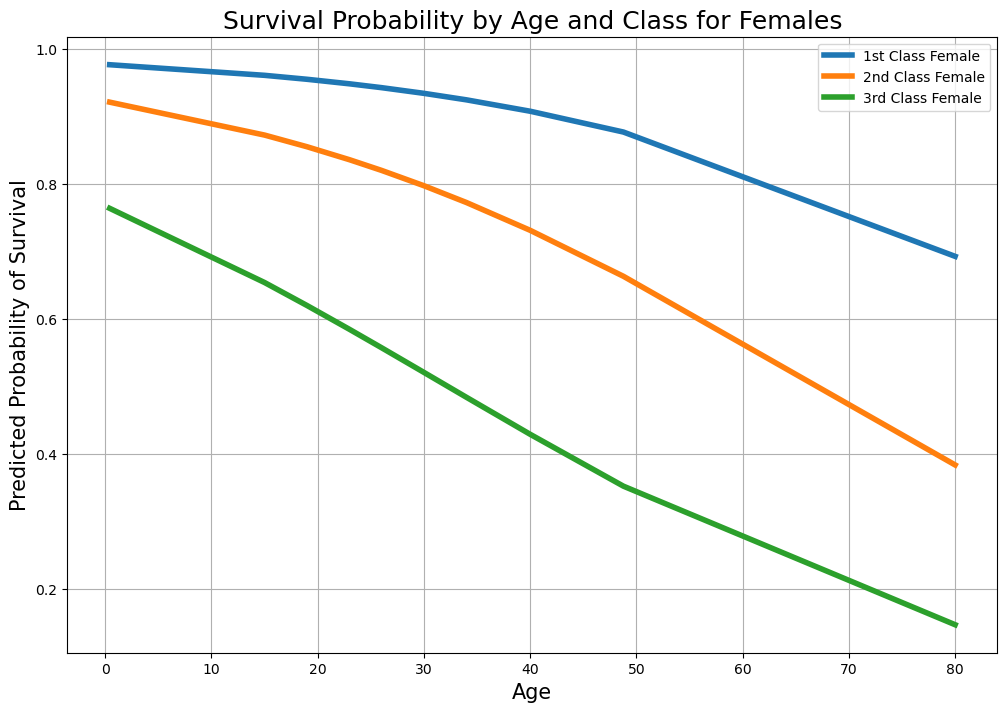

In [12]:
from statsmodels.sandbox.predict_functional import predict_functional

# Define the values for the predictors we are holding constant
values_1st = {"sex": "female", "pclass": 1}
values_2nd = {"sex": "female", "pclass": 2}
values_3rd = {"sex": "female", "pclass": 3}

# Generate predictions for each class
pr1, cb1, fv1 = predict_functional(result, "age", values=values_1st, ci_method="simultaneous")
pr2, cb2, fv2 = predict_functional(result, "age", values=values_2nd, ci_method="simultaneous")
pr3, cb3, fv3 = predict_functional(result, "age", values=values_3rd, ci_method="simultaneous")

# Convert log-odds to probabilities
prob1 = 1 / (1 + np.exp(-pr1))
prob2 = 1 / (1 + np.exp(-pr2))
prob3 = 1 / (1 + np.exp(-pr3))

# Plotting
plt.figure(figsize=(12, 8))
ax = plt.gca()
ax.plot(fv1, prob1, lw=4, label='1st Class Female')
ax.plot(fv2, prob2, lw=4, label='2nd Class Female')
ax.plot(fv3, prob3, lw=4, label='3rd Class Female')
ax.set_xlabel("Age", size=15)
ax.set_ylabel("Predicted Probability of Survival", size=15)
ax.grid(True)
ax.legend()
plt.title('Survival Probability by Age and Class for Females', size=18);


This plot beautifully illustrates our model's findings:

- The probability of survival is highest for females in 1st class and lowest for those in 3rd class.
- For all classes, the probability of survival generally decreases as age increases, as shown by the downward slope of the curves.
- The S-shape of the curves is the hallmark of logistic regression. The relationship between `age` and the *probability* of survival is non-linear, even though the relationship between `age` and the *log-odds* of survival is linear.

## Conclusion

In this notebook, we explored logistic regression using the Titanic dataset. We learned:
- The meaning of odds and log-odds, the mathematical foundation of logistic regression.
- How to fit a logistic regression model using `statsmodels`.
- How to interpret the model's coefficients as log-odds ratios, and how to convert them to odds ratios for easier understanding.
- The importance of conditional interpretation when multiple predictors are in the model.
- How to visualize the model's predictions to gain a clear, intuitive understanding of the relationships it has uncovered.